<a href="https://colab.research.google.com/github/kamrynphipps/Sephora-Data-Strategy-Analysis/blob/main/Sephora_Price_Rating_Correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df_products = pd.read_csv("/product_info.csv")

In [ ]:
reviews = ["/reviews_0-250.csv", "/reviews_250-500.csv", "/reviews_500-750.csv", "/reviews_750-1250.csv", "/reviews_1250-end.csv"]

In [ ]:
df_reviews = pd.DataFrame()
for review in reviews:
    df_reviews = pd.concat([df_reviews, pd.read_csv(review)])

/tmp/ipykernel_10839/1819708285.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews = pd.concat([df_reviews, pd.read_csv(review)])
/tmp/ipykernel_10839/1819708285.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews = pd.concat([df_reviews, pd.read_csv(review)])
/tmp/ipykernel_10839/1819708285.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews = pd.concat([df_reviews, pd.read_csv(review)])


In [ ]:
df_products.columns

Index(['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count',
       'rating', 'reviews', 'size', 'variation_type', 'variation_value',
       'variation_desc', 'ingredients', 'price_usd', 'value_price_usd',
       'sale_price_usd', 'limited_edition', 'new', 'online_only',
       'out_of_stock', 'sephora_exclusive', 'highlights', 'primary_category',
       'secondary_category', 'tertiary_category', 'child_count',
       'child_max_price', 'child_min_price'],
      dtype='object')

In [ ]:
# Convert to numeric (in case they’re strings)
df_products['price'] = pd.to_numeric(df_products['price_usd'], errors='coerce')
df_products['rating'] = pd.to_numeric(df_products['rating'], errors='coerce')

# Drop missing values
df_clean = df_products.dropna(subset=['price', 'rating'])

In [ ]:
correlation = df_clean['price'].corr(df_clean['rating'])
print("Correlation between price and rating:", correlation)

Correlation between price and rating: 0.0567378399965335


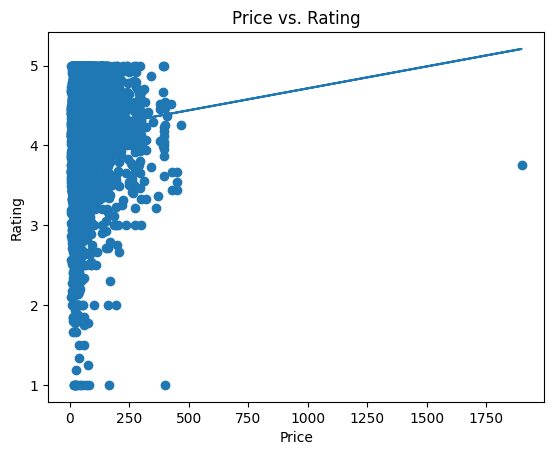

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = df_clean['price']
y = df_clean['rating']

# Create scatter plot
plt.scatter(x, y)

# Add trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

# Labels
plt.xlabel('Price')
plt.ylabel('Rating')
plt.title('Price vs. Rating')

plt.show()